## Name: Wong Kang Bin

In [1]:
## Admin Number: 244423Q

## Brief Overview (provide your video link here too)

https://drive.google.com/file/d/1B-lNFdVZUUYaPUb3Vg36caEHhV9KTNOW/view?usp=drive_link

<a id='table_of_contents'></a>

1. [Import libraries](#imports)
2. [Import data](#import_data)
3. [Data exploration](#data_exploration)
4. [Data cleaning and preparation](#data_cleaning)
5. [Model training](#model_training)<br>
6. [Model comparsion](#model_comparsion)<br>
7. [Tuning](#tuning)<br>
8. [Validation](#validation)<br>

# 1. Import libraries <a id='imports'></a>
[Back to top](#table_of_contents)

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.stats import skew

# Libraries to help with machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline

ModuleNotFoundError: No module named 'statsmodels'

# 2. Import data <a id='import_data'></a>
[Back to top](#table_of_contents)

In [ ]:
diabetes_df = pd.read_csv('diabetes.csv')

In [ ]:
diabetes_df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


# 3. Data exploration <a id='data_exploration'></a>
[Back to top](#table_of_contents)

**Data Understanding**

In [ ]:
# Get the number of rows and columns
num_rows, num_columns = diabetes_df.shape
# Print the results
print(f'Number of rows: {num_rows}')
print(f'Number of columns: {num_columns}')

Number of rows: 253680
Number of columns: 22


In [ ]:
# View data types of all collumns using the info() method and verify if there are any missing values
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_binary       253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

In [ ]:
print("Number of missing records:", diabetes_df.isnull().sum())

Number of missing records: Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


**Observations**
- The data types used for all collumns are integers.
- No missing records are seen based on the non-null count.

Based on our observatons, it would be advisable to categorise certain numerical collumns into meaningful categorical names or ranges. For this case, age and income will be converted to ranges and education, gender and General Health will be converted to categories. This will help in enhancing the clarity of data intepretation

In [ ]:
num_of_duplicates = diabetes_df.duplicated().sum()
print('Number of Duplicates Discovered:', num_of_duplicates)

Number of Duplicates Discovered: 24206


Duplicated records could likely represent a same exact patient record appeared more than once.

In [ ]:
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


As majority of the numerical columns above are either binary or categorical, we will dive deeper into analysing the descriptive statistics of numerical collumns that are non binary or non-categorical. In this case, we will be analysing for BMI, Mental Health and Physical Health.

In [ ]:
diabetes_df[['BMI', 'MentHlth', 'PhysHlth']].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0


**Observations**
- The maximum BMI value of 98 might be highly unusual in a real-world context.
- A significantly high number of people with 0 to 3 days of mental and physical health despite a minority showing long-term issues as the maximum value of Mental and Physical Health shows 30 days.
- The mean value across these 3 columns are higher than the median indicating that the data is positively skewed.

In [ ]:
# Frequency count of diabetic or non-diabetic cases where 0 represents non-diabetic and 1 represents diabeteic
diabetes_df['Diabetes_binary'].value_counts()

Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

**Exploratory Data Analysis (EDA)**

<Axes: title={'center': 'BMI Distribution'}, xlabel='BMI'>

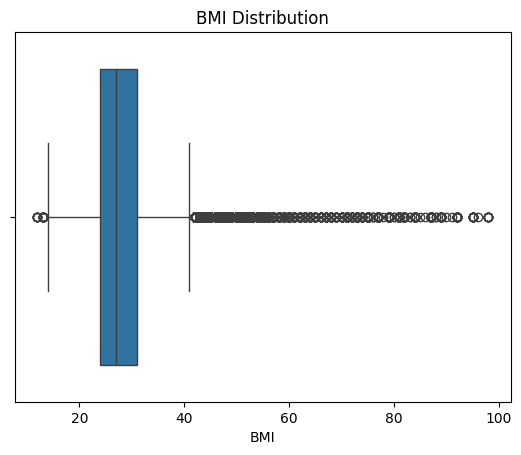

In [ ]:
# 1. BMI Distribution
plt.title('BMI Distribution')
sns.boxplot(data=diabetes_df, x='BMI')

The median BMI is about 27 and the average BMI is 28.3 with health records being skewed to the right. A wide range of extreme outliers points can be observed when the BMI goes beyond 40. This means that while most people have a BMI of under 40, there is a significant subgroup of people with extreme high BMI values that pulls the average much higher than the median.  

<Axes: title={'center': 'Diabeteic Cases Distribution'}, xlabel='Non-Diabetic(0) or Diabetic(1)', ylabel='count'>

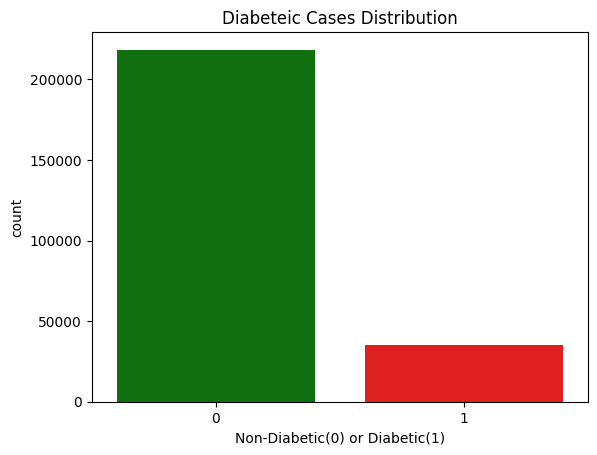

In [ ]:
# 2. Diabetic Cases Distribution

# 0 represents non-diabetic and 1 represents diabetic
plt.title('Diabeteic Cases Distribution')
plt.xlabel('Non-Diabetic(0) or Diabetic(1)')
sns.countplot(data=diabetes_df, x='Diabetes_binary', hue='Diabetes_binary', palette=['green', 'red'], legend=False)

Majority of the health records are non-diabetic cases highlighting class imbalance.

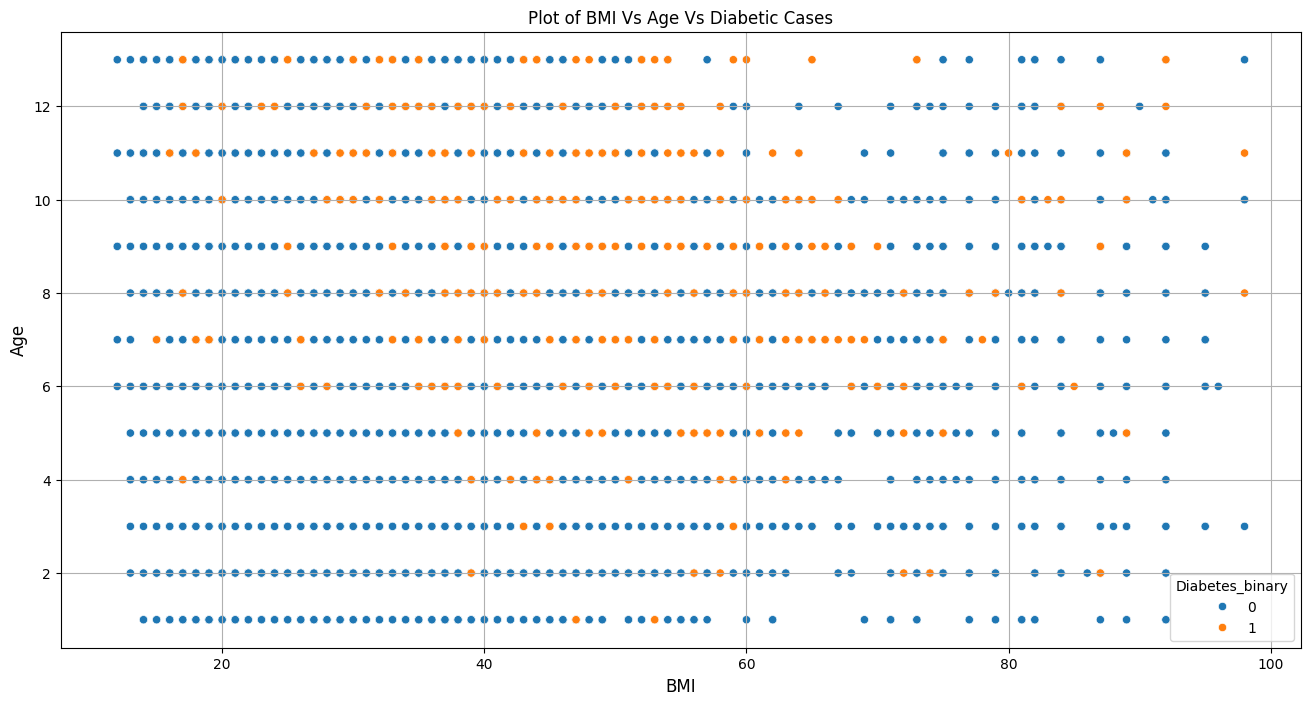

In [ ]:
# 3. Plot of BMI Vs Age Vs Diabetic Cases
plt.figure(figsize=(16,8))
plt.title('Plot of BMI Vs Age Vs Diabetic Cases', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Age', fontsize=12)
sns.scatterplot(data=diabetes_df,x='BMI',y= 'Age', hue='Diabetes_binary')
plt.grid(True)
plt.show()

Diabetic cases are more commonly found around older age groups and higher BMI indicating that high BMI and old age are primary diabetic risk factors.

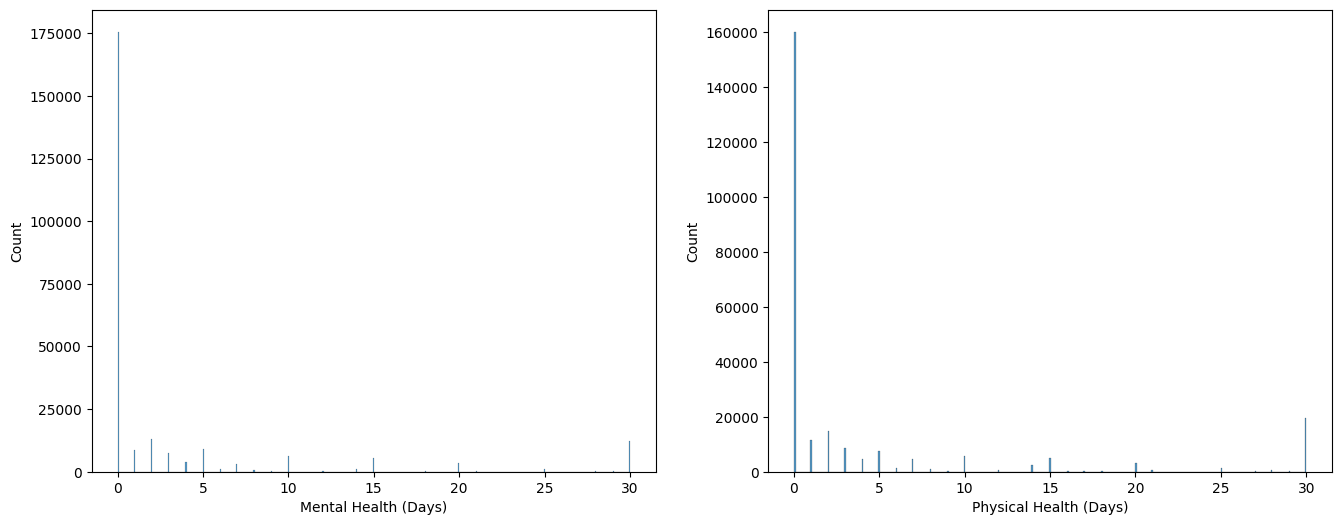

In [ ]:
# 4. Distribution of Patients with Poor Mental and Physical Health in days
fig, ax = plt.subplots(1,2, figsize=(16,6))

# Mental Health Distribution
sns.histplot(data = diabetes_df, x = 'MentHlth', ax=ax[0])

ax[0].set_xlabel('Mental Health (Days)')



# Physical Health Distribution
sns.histplot(data = diabetes_df, x = 'PhysHlth', ax=ax[1])
ax[1].set_xlabel('Physical Health (Days)')



plt.show()

A significant number of people generally have no issues with their mental and physical health. Unfortunately, at least 20,000 people have mental and physical health issues for at least 30 days which suggests a sub-group with chronic conditions.

<Axes: title={'center': 'General Health Distribution'}, xlabel='GenHlth', ylabel='count'>

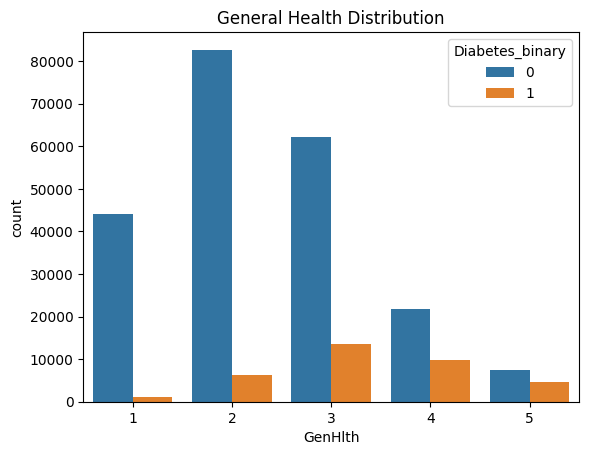

In [ ]:
# 5. General Health Distribution
plt.title('General Health Distribution')
sns.countplot(data=diabetes_df, x='GenHlth', hue='Diabetes_binary')

As general health increases from category 1 (Excellent) to category 5 (Poor), the proportion of diabetic cases (orange bar) relative to non-diabetic cases (blue bar) grows significantly. A clear peak of diabetic cases is seen at category 3(Good) indicating a significant portion of diabetic cases still perceive themselves as generally positive, highlighting the importance of clinical screening over self-assessment alone.

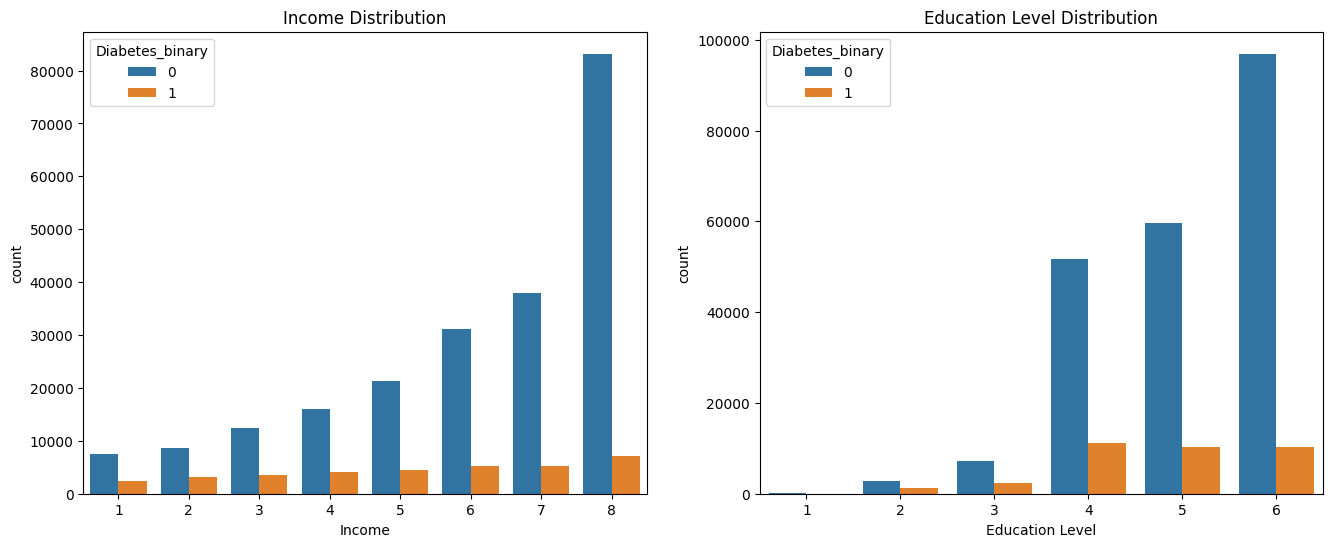

In [ ]:
# 6. Income and Education Level Distribution
fig, ax = plt.subplots(1,2, figsize=(16,6))

# Income Distribution
sns.countplot(data=diabetes_df, x='Income', ax=ax[0], hue='Diabetes_binary')
ax[0].set_title('Income Distribution')
ax[0].set_xlabel('Income')


# Education Level Distribution
sns.countplot(data=diabetes_df, x='Education', ax=ax[1], hue='Diabetes_binary')
ax[1].set_title('Education Level Distribution')
ax[1].set_xlabel('Education Level')



plt.show()


People may still succumb to diabetes regardless of how much income you have. Majority of the patients have already graduated from school which implies that they are mostly working adults who are likely to get diabetes as most diabetic cases occurs from older age groups.

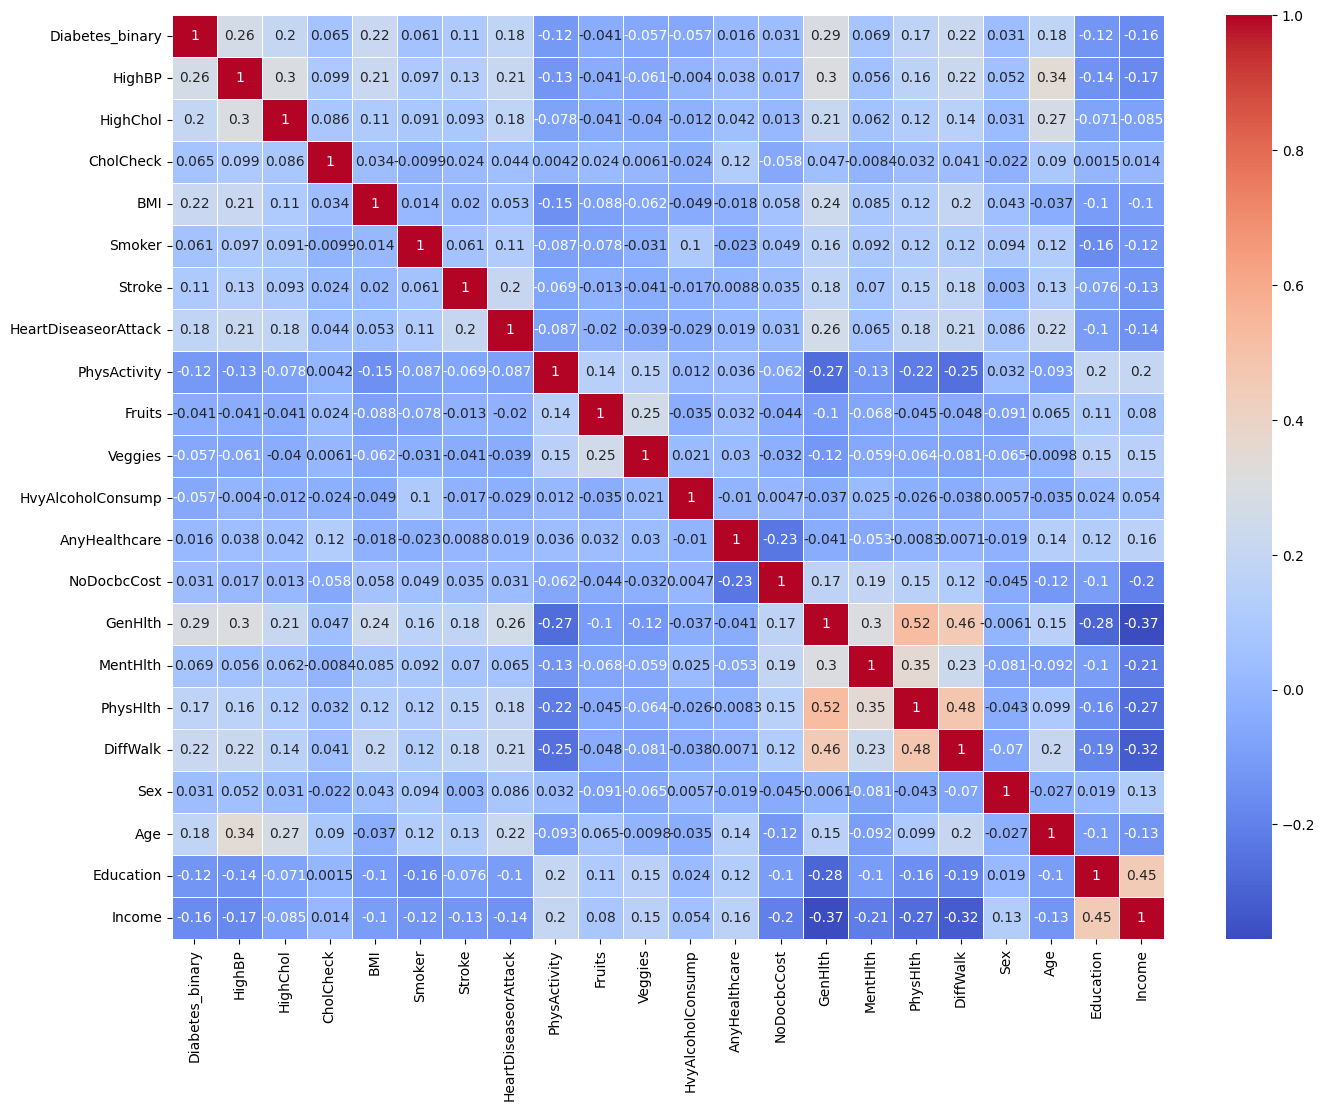

In [ ]:
# 7. Correlation Matrix of numerical Features
plt.figure(figsize=(16,12))
sns.heatmap(diabetes_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

The correlation matrix reveals that while most features have a weak correlation with each other, BMI, General Health and High Blood Pressure emerged as top predictors in diabetic cases. Another way to determine if there is multicolinearity to use the Variable Importance Factor (VIF) method.

In [ ]:
# Select numerical features only (exclude target)
num_features = diabetes_df.drop(columns=['Diabetes_binary']).columns

X = diabetes_df[num_features].copy()

# Standardize features (recommended for VIF stability)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create VIF DataFrame
vif_df = pd.DataFrame()
vif_df["feature"] = num_features
vif_df["VIF"] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_df

,feature,VIF
0,HighBP,1.330684
1,HighChol,1.173313
2,CholCheck,1.032822
3,BMI,1.139724
4,Smoker,1.091787
5,Stroke,1.081070
6,HeartDiseaseorAttack,1.171917
7,PhysActivity,1.157311
8,Fruits,1.112533
9,Veggies,1.112385


No multicollinearity dectected as all pairwise features falls below the 0.85 threshold for correlations. Furthermore, VIF value of all features calculated with standard scaling all falls below 5. The correlation matrix generally shows a weak relationship between the variables. This confirms the findings from the correlation analysis and quantitatively demonstrates the abscence of multicollinearity in the dataset.

# 4. Data cleaning and preparation <a id='data_cleaning'></a>
[Back to top](#table_of_contents)

In [ ]:
## Before data cleaning
diabetes_df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


**(1) Removing Duplicates**

In [ ]:
# Initial number of rows and collumns before removing duplicates
num_rows, num_columns = diabetes_df.shape
# Print the results
print('BEFORE REMOVING DUPLICATES')
print("="*30+"\n")
print(f'Number of rows: {num_rows}')
print(f'Number of columns: {num_columns}')

BEFORE REMOVING DUPLICATES

Number of rows: 253680
Number of columns: 22


In [ ]:
# 1. Drop Duplicates
diabetes_df = diabetes_df.drop_duplicates()

In [ ]:
# Get the number of rows and columns of updated dataframe
num_rows, num_columns = diabetes_df.shape
# Print the results
print('AFTER REMOVING DUPLICATES')
print("="*30+"\n")
print(f'Number of rows: {num_rows}')
print(f'Number of columns: {num_columns}')

AFTER REMOVING DUPLICATES

Number of rows: 229474
Number of columns: 22


**(2) Removing BMI Outliers**

In [ ]:
Q1 = diabetes_df['BMI'].quantile(0.25)
Q3 = diabetes_df['BMI'].quantile(0.75)
IQR = Q3- Q1
diabetes_filtered_df = diabetes_df[(diabetes_df['BMI'] >= (Q1 - 1.5 * IQR)) & (diabetes_df['BMI'] <= (Q3 + 1.5 * IQR))].copy()
# Add a .copy() method to filter dataset so that no warnings can be issued when categorising numerical features in the next step
print('Max BMI Value:', diabetes_filtered_df['BMI'].max())
print('Min BMI Value:', diabetes_filtered_df['BMI'].min())


Max BMI Value: 44
Min BMI Value: 12


**(3) Convert certain numerical features to categorical features**

In [ ]:
# Convert numerical features into categorical features (Age, Income, Education, Gender, General Health)
# age and income will be converted to ranges and education, gender and General Health will be converted to categories.
diabetes_filtered_df["Age"] = pd.cut(
    diabetes_filtered_df["Age"],
    bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    labels=["18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80 or older"]
)

diabetes_filtered_df["Income"] = pd.cut(
    diabetes_filtered_df["Income"],
    bins=[0, 1, 2, 3, 4, 5, 6, 7, 8],
    labels=["Less Than $10,000", "$10,000-$20,000", "$20,000-$25,000", "$25,000-$30,000", "$30,000-$35,000", 
            "$35,000-$55,000", "$55,000-$75,000", "$75,000 or more"]
)

diabetes_filtered_df["Education"] = pd.cut(
    diabetes_filtered_df["Education"],
    bins=[0, 1, 2, 3, 4, 5, 6],
    labels=["Never Attended School or Kindergarten", "Elementary", "Some High School", 
            "High school graduate", "Some college or technical school", "College Graduate"]
)

diabetes_filtered_df["Sex"] = pd.cut(
    diabetes_filtered_df["Sex"],
    bins=[-0.1, 0.5, 1.1],
    labels=["Female", "Male"]
)

diabetes_filtered_df["GenHlth"] = pd.cut(
    diabetes_filtered_df["GenHlth"],
    bins=[0, 1, 2, 3, 4, 5],
    labels=["Excellent", "Very Good", "Good", "Fair", "Poor"]
)



**(4) One-Hot Encoding**

In [ ]:
# This turns the text labels back into numbers so the models can do its mathamatical functions
categorical_cols = ["Age", "Income", "Education", "Sex", "GenHlth"]
diabetes_final_df = pd.get_dummies(diabetes_filtered_df, columns=categorical_cols, drop_first=False)

# 5. Model training <a id='model_training'></a>
[Back to top](#table_of_contents)

In [ ]:
# Features (all columns except 'Diabetes_Binary')
X = diabetes_final_df.drop('Diabetes_binary', axis=1)  
y = diabetes_final_df['Diabetes_binary']         

In [ ]:
X.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,Education_High school graduate,Education_Some college or technical school,Education_College Graduate,Sex_Female,Sex_Male,GenHlth_Excellent,GenHlth_Very Good,GenHlth_Good,GenHlth_Fair,GenHlth_Poor
0,1,1,1,40,1,0,0,0,0,1,...,True,False,False,True,False,False,False,False,False,True
1,0,0,0,25,1,0,0,1,0,0,...,False,False,True,True,False,False,False,True,False,False
2,1,1,1,28,0,0,0,0,1,0,...,True,False,False,True,False,False,False,False,False,True
3,1,0,1,27,0,0,0,1,1,1,...,False,False,False,True,False,False,True,False,False,False
4,1,1,1,24,0,0,0,1,1,1,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Diabetes_binary, dtype: int64

In [ ]:
# splitting data into train and test sets into 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Check class distribution to verify stratification
print("Original Dataset Class Distribution:\n", y.value_counts())
print("Training Set Class Distribution:\n", y_train.value_counts())
print("Testing Set Class Distribution:\n", y_test.value_counts())

Original Dataset Class Distribution:
 Diabetes_binary
0    190735
1     33101
Name: count, dtype: int64
Training Set Class Distribution:
 Diabetes_binary
0    133515
1     23170
Name: count, dtype: int64
Testing Set Class Distribution:
 Diabetes_binary
0    57220
1     9931
Name: count, dtype: int64


In [ ]:
# Use stanadard scaling of features to ensure model loads faster
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Defined models again for classification report and confusion matrix
lr = LogisticRegression(solver='lbfgs', max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(n_jobs = -1) # Use all CPU cores for Random Forest by using n_jobs = -1 to enable parralism
ab = AdaBoostClassifier()
gb = GradientBoostingClassifier()
svc = LinearSVC() 
# As the default SVC models are mathematically intense, it will take a computational long time to run especially when training against a huge dataset
# Thus, LinearSVC() is used to limit SVC data making the model run faster.

# Fit training data into all models
lr.fit(X_train_scaled, y_train)
dt.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
ab.fit(X_train_scaled, y_train)
gb.fit(X_train_scaled, y_train)
svc.fit(X_train_scaled, y_train)

LinearSVC()

# 6. Model comparsion <a id='model_comparsion'></a>
[Back to top](#table_of_contents)

In [ ]:
# Classification Report of all 6 models

# Logistic Regression classification report
print(classification_report(y_test, lr.predict(X_test_scaled)))

# Logistic Regression accuracy score
lr_acc_score = accuracy_score(y_test, lr.predict(X_test_scaled))
print("Logistic Regression Accuracy Score: " + str(lr_acc_score) + "\n")

# Decision Tree classification report
print(classification_report(y_test, dt.predict(X_test_scaled)))

# Decision Tree accuracy score
dt_acc_score = accuracy_score(y_test, dt.predict(X_test_scaled))
print("Decision Tree Accuracy Score: " + str(dt_acc_score) + "\n")


# Random Forest classification report
print(classification_report(y_test, rf.predict(X_test_scaled)))

# Random Forest accuracy score
rf_acc_score = accuracy_score(y_test, rf.predict(X_test_scaled))
print("Random Forest Accuracy Score: " + str(rf_acc_score) + "\n")

# Ada Boost classification report
print(classification_report(y_test, ab.predict(X_test_scaled)))

# Ada Boost accuracy score
ab_acc_score = accuracy_score(y_test, ab.predict(X_test_scaled))
print("Ada Boost Accuracy Score: " + str(ab_acc_score) + "\n")

# Gradient Boosting classification report
print(classification_report(y_test, gb.predict(X_test_scaled)))

# Gradient Boosting accuracy score
gb_acc_score = accuracy_score(y_test, gb.predict(X_test_scaled))
print("Gradient Boosting Accuracy Score: " + str(gb_acc_score) + "\n")

# Support Vector Machine classification report
print(classification_report(y_test, svc.predict(X_test_scaled)))

# Support Vector Machine accuracy score
svc_acc_score = accuracy_score(y_test, svc.predict(X_test_scaled))
print("Support Vector Machine Accuracy Score: " + str(svc_acc_score) + "\n")

              precision    recall  f1-score   support

           0       0.87      0.98      0.92     57220
           1       0.55      0.15      0.23      9931

    accuracy                           0.86     67151
   macro avg       0.71      0.56      0.58     67151
weighted avg       0.82      0.86      0.82     67151

Logistic Regression Accuracy Score: 0.8559812958853926

              precision    recall  f1-score   support

           0       0.88      0.86      0.87     57220
           1       0.28      0.31      0.30      9931

    accuracy                           0.78     67151
   macro avg       0.58      0.59      0.58     67151
weighted avg       0.79      0.78      0.79     67151

Decision Tree Accuracy Score: 0.7810308111569448

              precision    recall  f1-score   support

           0       0.87      0.97      0.91     57220
           1       0.43      0.14      0.21      9931

    accuracy                           0.85     67151
   macro avg       0.6

Text(1180.4281045751634, 0.5, 'Actual')

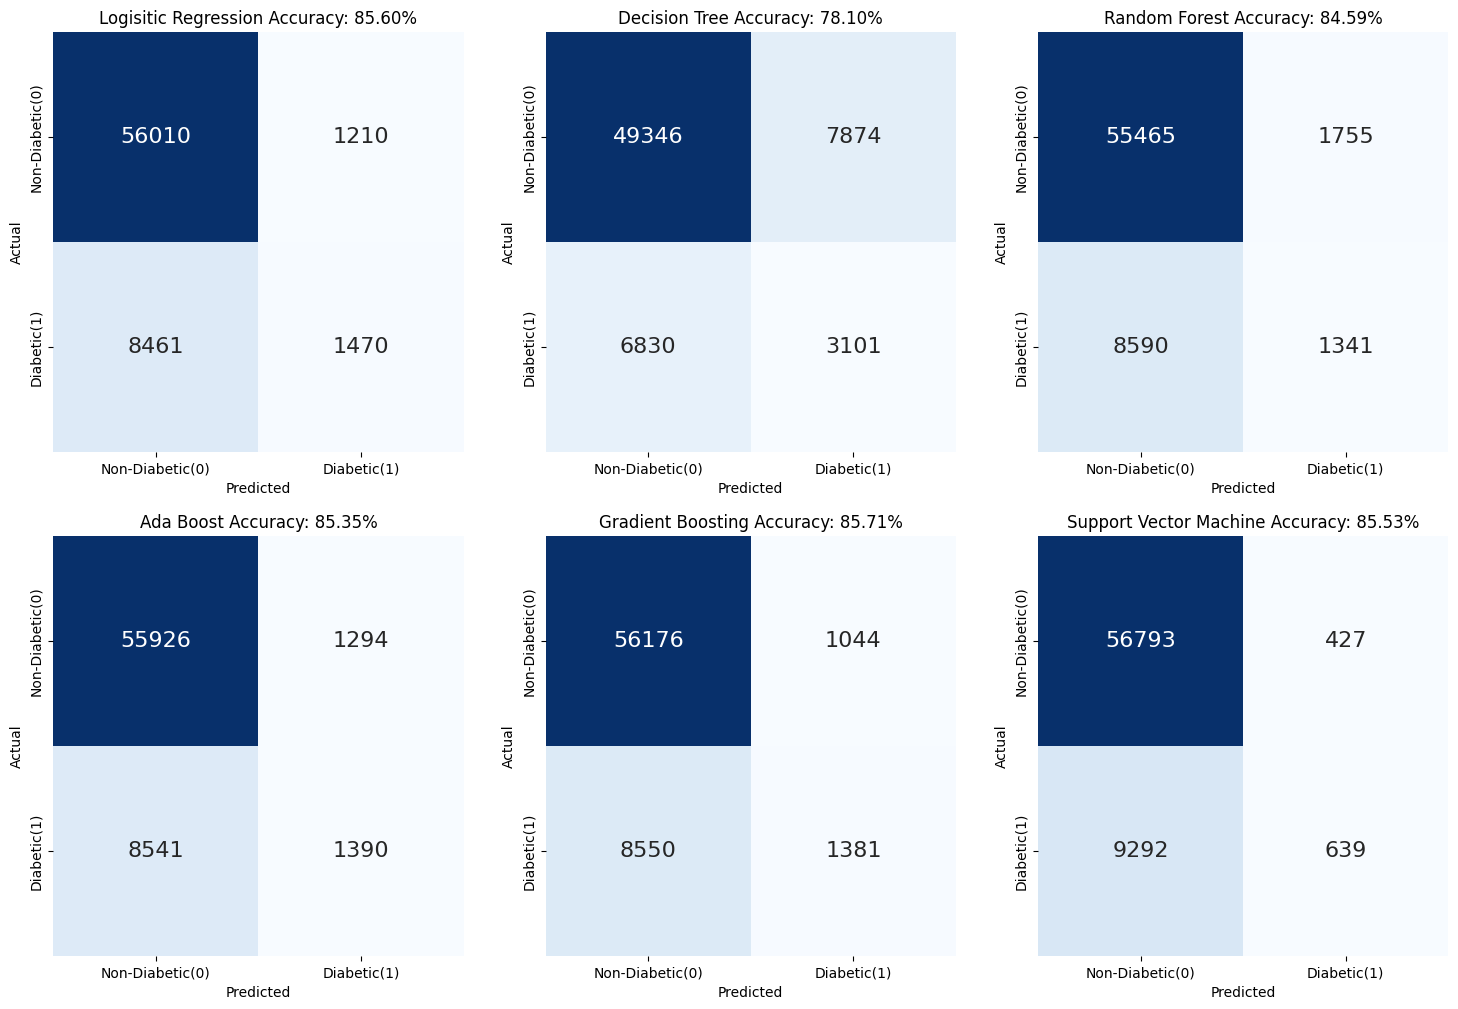

In [ ]:
lr_cm = confusion_matrix(y_test, lr.predict(X_test_scaled))
dt_cm = confusion_matrix(y_test, dt.predict(X_test_scaled))
rf_cm = confusion_matrix(y_test, rf.predict(X_test_scaled))
ab_cm = confusion_matrix(y_test, ab.predict(X_test_scaled))
gb_cm = confusion_matrix(y_test, gb.predict(X_test_scaled))
svc_cm = confusion_matrix(y_test, svc.predict(X_test_scaled))


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sns.heatmap(lr_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][0]
            )
axes[0][0].set_title(f"Logisitic Regression Accuracy: {lr_acc_score:.2%}")
axes[0][0].set_xlabel("Predicted")
axes[0][0].set_ylabel("Actual")

sns.heatmap(dt_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][1]
            )
axes[0][1].set_title(f"Decision Tree Accuracy: {dt_acc_score:.2%}")
axes[0][1].set_xlabel("Predicted")
axes[0][1].set_ylabel("Actual")

sns.heatmap(rf_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][2]
            )
axes[0][2].set_title(f"Random Forest Accuracy: {rf_acc_score:.2%}")
axes[0][2].set_xlabel("Predicted")
axes[0][2].set_ylabel("Actual")


sns.heatmap(ab_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][0]
            )
axes[1][0].set_title(f"Ada Boost Accuracy: {ab_acc_score:.2%}")
axes[1][0].set_xlabel("Predicted")
axes[1][0].set_ylabel("Actual")


sns.heatmap(gb_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][1]
            )
axes[1][1].set_title(f"Gradient Boosting Accuracy: {gb_acc_score:.2%}")
axes[1][1].set_xlabel("Predicted")
axes[1][1].set_ylabel("Actual")


sns.heatmap(svc_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][2]
            )
axes[1][2].set_title(f"Support Vector Machine Accuracy: {svc_acc_score:.2%}")
axes[1][2].set_xlabel("Predicted")
axes[1][2].set_ylabel("Actual")

Typically, we would use the accuracy metric to determine which model performs the best. However, it is not sufficient enough for this imbalanced dataset as there are other evaluation metrics such as F1 score, precision and recall rate to evaluate the best model. For example, a model could achieve a high accuracy in predicting the majority class which are non-diabetic cases while failing to identify diabetic cases completely that could critically impact the healthcare system. To ensure that the model is fully effective in predicting diabetic cases, it is crucial to evaluate precision for predicting diabetic cases, recall in ensuring that no diabetic cases are being misclassified and F1 score which serves as a harmonic mean of precision and recall. Thus, it is important to consider using other evaluation metrics in model evaluation instead of relying solely on accuracy.

**Model Comparison using Evaluation Metrics**:
- Accuracy: All models except for Decision Tree have a very close accuracy score against each other ranging from 84.64% (Random Forest) to Gradient Boosting (85.71%) with Decision Tree at 78.04%. Given that the context of this project is to predict diabetic cases, it makes sense if Decision Tree has the lowest accuracy since it is a white box model that produce all the various reasons behind diabetic cases which are typically computationally complex to intepret and it is prone to overfitting. As such we will not be using Decision Tree for hyperparameter tuning.
- Precision: Precision can be used to analyse the prediction rate of diabetic or non diabetic cases. In this case, Support Vector Machine would be effective in predicting diabetic cases correctly as it outperoms other models with a precision of 0,60. Unfortunately, Decision Tree has the lowest precision of 0.28 in predicting diabetic cases leaving Random Forest at 0.44 and the remaining 3 models with at least 0.5 precision. On the other hand, Decision Tree suprisingly outperorms other models by a margin in predicting non-diabetic cases with a precision of 0.88 followed by 0.87 from 4 models and 0.86 from Support Vector Machine.
- Recall: Recall can be use to identify the proportion of correctly classified out of all actual diabetic or non diabetic cases. For diabetic cases, Decision Tree dominates other models in identifying diabetic cases with a recall rate of 0.31 while Support Vector Machine has the lowest recall rate of 0.06 leaving the remaining 4 models at a recall rate of 0.14 (Remaining 3 models) and 0.15 (Logistic Regression). However, Support Vector Machine outperforms other models by a margin with a recall rate of 0.99 in identifying non-diabetic cases, followed by Logistic Regression, Ada Boost and Gradient Boost at 0.98, Random Forest at 0.97 and Decision Tree at 0.86. Due to its low recall rate in diabetic cases, we can conclude that a majority of diabetics cases were actually misclassified due to how imbalance the data is as the model was able to correctly identify non-diabetic cases which represents the majority.
- F1 Score: For the diabetic cases, Decision Tree surprisingly outperforms other models with a F1 Score of 0.29 followed by Logistic Regression at 0.23, Ada and Gradient Boost at 0.22, Random Forest at 0.21 and Support Vector Machine at 0.12. On the other hand for non-diabetic cases, Logisitic Regression, Ada Boost, Gradient Boost and Support Vector Machine outperforms other models with a F1 score of 0.92 leaving Random Forest at 0.91 and Decision Tree at 0.87.


**Conclusion:**

Based on the above results, we can conclude that despite its high overall model accuracy, the accuracy metric is misleading as it reflects the models' ability to identify diabetic cases due to low recall rate given that the data is super imbalanced making majority of the diabetic cases misclassified. While F1 score is mainly used to balance the harmonic mean of precision and recall, it is still not super efffective in diabetic cases due to its low F1 score. Similarly, the model is more precise in predicting non-diabetic cases than diabeitc cases due to its precision rate. To improve the model's performance on the minority class (Diabetic Cases), we can use SMOTE (Synthetic Minority Over-sampling Technique). This technique creates synthetic examples of the minority class rather than just duplicating them, helping the model to learn Diabetic Cases better. Subsequently, we will re-evaluate the model performance using SMOTE and pick two best suitable models to tune.

# 7. Tuning <a id='tuning'></a>

[Back to top](#table_of_contents)

In [ ]:
print("Training set class distribution (before SMOTE):")
print(y_train.value_counts())
print("\nClass proportion:")
print(y_train.value_counts(normalize=True).round(3))

Training set class distribution (before SMOTE):
Diabetes_binary
0    133515
1     23170
Name: count, dtype: int64

Class proportion:
Diabetes_binary
0    0.852
1    0.148
Name: proportion, dtype: float64


In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Training set class distribution (after SMOTE):")
print(pd.Series(y_train_sm).value_counts())




Training set class distribution (after SMOTE):
Diabetes_binary
1    133515
0    133515
Name: count, dtype: int64


In [ ]:
# Define models with standard scaling for SMOTE

In [ ]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(solver='lbfgs', max_iter=1000))
])

logistic_model.fit(X_train_sm, y_train_sm)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000))])

In [ ]:
decision_tree_model = Pipeline([
    ("scaler", StandardScaler()),
    ("dt", DecisionTreeClassifier())
])

decision_tree_model.fit(X_train_sm, y_train_sm)

Pipeline(steps=[('scaler', StandardScaler()), ('dt', DecisionTreeClassifier())])

In [ ]:
random_forest_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf",  RandomForestClassifier(n_jobs=-1))
])

random_forest_model.fit(X_train_sm, y_train_sm)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf', RandomForestClassifier(n_jobs=-1))])

In [ ]:
ada_boost_model = Pipeline([
    ("scaler", StandardScaler()),
    ("adaboost",  AdaBoostClassifier())
])


ada_boost_model.fit(X_train_sm, y_train_sm)

Pipeline(steps=[('scaler', StandardScaler()),
                ('adaboost', AdaBoostClassifier())])

In [ ]:
gradient_boost_model = Pipeline([
    ("scaler", StandardScaler()),
    ("gradientboost",  GradientBoostingClassifier())
])


gradient_boost_model.fit(X_train_sm, y_train_sm)

Pipeline(steps=[('scaler', StandardScaler()),
                ('gradientboost', GradientBoostingClassifier())])

In [ ]:
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc",  LinearSVC())
])

svc_model.fit(X_train_sm, y_train_sm)

Pipeline(steps=[('scaler', StandardScaler()), ('svc', LinearSVC())])

In [ ]:
log_pred_smote = logistic_model.predict(X_test)
dt_pred_smote = decision_tree_model.predict(X_test)
rf_pred_smote = random_forest_model.predict(X_test)
ab_pred_smote = ada_boost_model.predict(X_test)
gb_pred_smote = gradient_boost_model.predict(X_test)
svc_pred_smote = svc_model.predict(X_test)

# Classification Report of all 6 models BEFORE SMOTE
print("=== Classification Report of All Models BEFORE SMOTE ===")

# Logistic Regression classification report
print(classification_report(y_test, lr.predict(X_test_scaled)))

# Logistic Regression accuracy score
lr_acc_score = accuracy_score(y_test, lr.predict(X_test_scaled))
print("Logistic Regression Accuracy Score: " + str(lr_acc_score) + "\n")

# Decision Tree classification report
print(classification_report(y_test, dt.predict(X_test_scaled)))

# Decision Tree accuracy score
dt_acc_score = accuracy_score(y_test, dt.predict(X_test_scaled))
print("Decision Tree Accuracy Score: " + str(dt_acc_score) + "\n")


# Random Forest classification report
print(classification_report(y_test, rf.predict(X_test_scaled)))

# Random Forest accuracy score
rf_acc_score = accuracy_score(y_test, rf.predict(X_test_scaled))
print("Random Forest Accuracy Score: " + str(rf_acc_score) + "\n")

# Ada Boost classification report
print(classification_report(y_test, ab.predict(X_test_scaled)))

# Ada Boost accuracy score
ab_acc_score = accuracy_score(y_test, ab.predict(X_test_scaled))
print("Ada Boost Accuracy Score: " + str(ab_acc_score) + "\n")

# Gradient Boosting classification report
print(classification_report(y_test, gb.predict(X_test_scaled)))

# Gradient Boosting accuracy score
gb_acc_score = accuracy_score(y_test, gb.predict(X_test_scaled))
print("Gradient Boosting Accuracy Score: " + str(gb_acc_score) + "\n")

# Support Vector Machine classification report
print(classification_report(y_test, svc.predict(X_test_scaled)))

# Support Vector Machine accuracy score
svc_acc_score = accuracy_score(y_test, svc.predict(X_test_scaled))
print("Support Vector Machine Accuracy Score: " + str(svc_acc_score) + "\n")


print("\n=== Classification Report of All Models After SMOTE ===")

# Logistic Regression classification report
print(classification_report(y_test, log_pred_smote))

# Logistic Regression accuracy score
lr_smote_acc_score = accuracy_score(y_test, log_pred_smote)
print("Logistic Regression Accuracy Score: " + str(lr_smote_acc_score) + "\n")

# Decision Tree classification report
print(classification_report(y_test, dt_pred_smote))

# Decision Tree accuracy score
dt_smote_acc_score = accuracy_score(y_test, dt_pred_smote)
print("Decision Tree Accuracy Score: " + str(dt_smote_acc_score) + "\n")


# Random Forest classification report
print(classification_report(y_test, rf_pred_smote))

# Random Forest accuracy score
rf_smote_acc_score = accuracy_score(y_test, rf_pred_smote)
print("Random Forest Accuracy Score: " + str(rf_smote_acc_score) + "\n")

# Ada Boost classification report
print(classification_report(y_test, ab_pred_smote))

# Ada Boost accuracy score
ab_smote_acc_score = accuracy_score(y_test, ab_pred_smote)
print("Ada Boost Accuracy Score: " + str(ab_smote_acc_score) + "\n")

# Gradient Boosting classification report
print(classification_report(y_test,gb_pred_smote))

# Gradient Boosting accuracy score
gb_smote_acc_score = accuracy_score(y_test, gb_pred_smote)
print("Gradient Boosting Accuracy Score: " + str(gb_smote_acc_score) + "\n")

# Support Vector Machine classification report
print(classification_report(y_test, svc_pred_smote))

# Support Vector Machine accuracy score
svc_smote_acc_score = accuracy_score(y_test, svc_pred_smote)
print("Support Vector Machine Accuracy Score: " + str(svc_smote_acc_score) + "\n")



=== Classification Report of All Models BEFORE SMOTE ===
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     57220
           1       0.55      0.15      0.23      9931

    accuracy                           0.86     67151
   macro avg       0.71      0.56      0.58     67151
weighted avg       0.82      0.86      0.82     67151

Logistic Regression Accuracy Score: 0.8559812958853926

              precision    recall  f1-score   support

           0       0.88      0.86      0.87     57220
           1       0.28      0.31      0.30      9931

    accuracy                           0.78     67151
   macro avg       0.58      0.59      0.58     67151
weighted avg       0.79      0.78      0.79     67151

Decision Tree Accuracy Score: 0.7810308111569448

              precision    recall  f1-score   support

           0       0.87      0.97      0.91     57220
           1       0.43      0.14      0.21      9931

    accuracy       

Text(1180.4281045751634, 0.5, 'Actual')

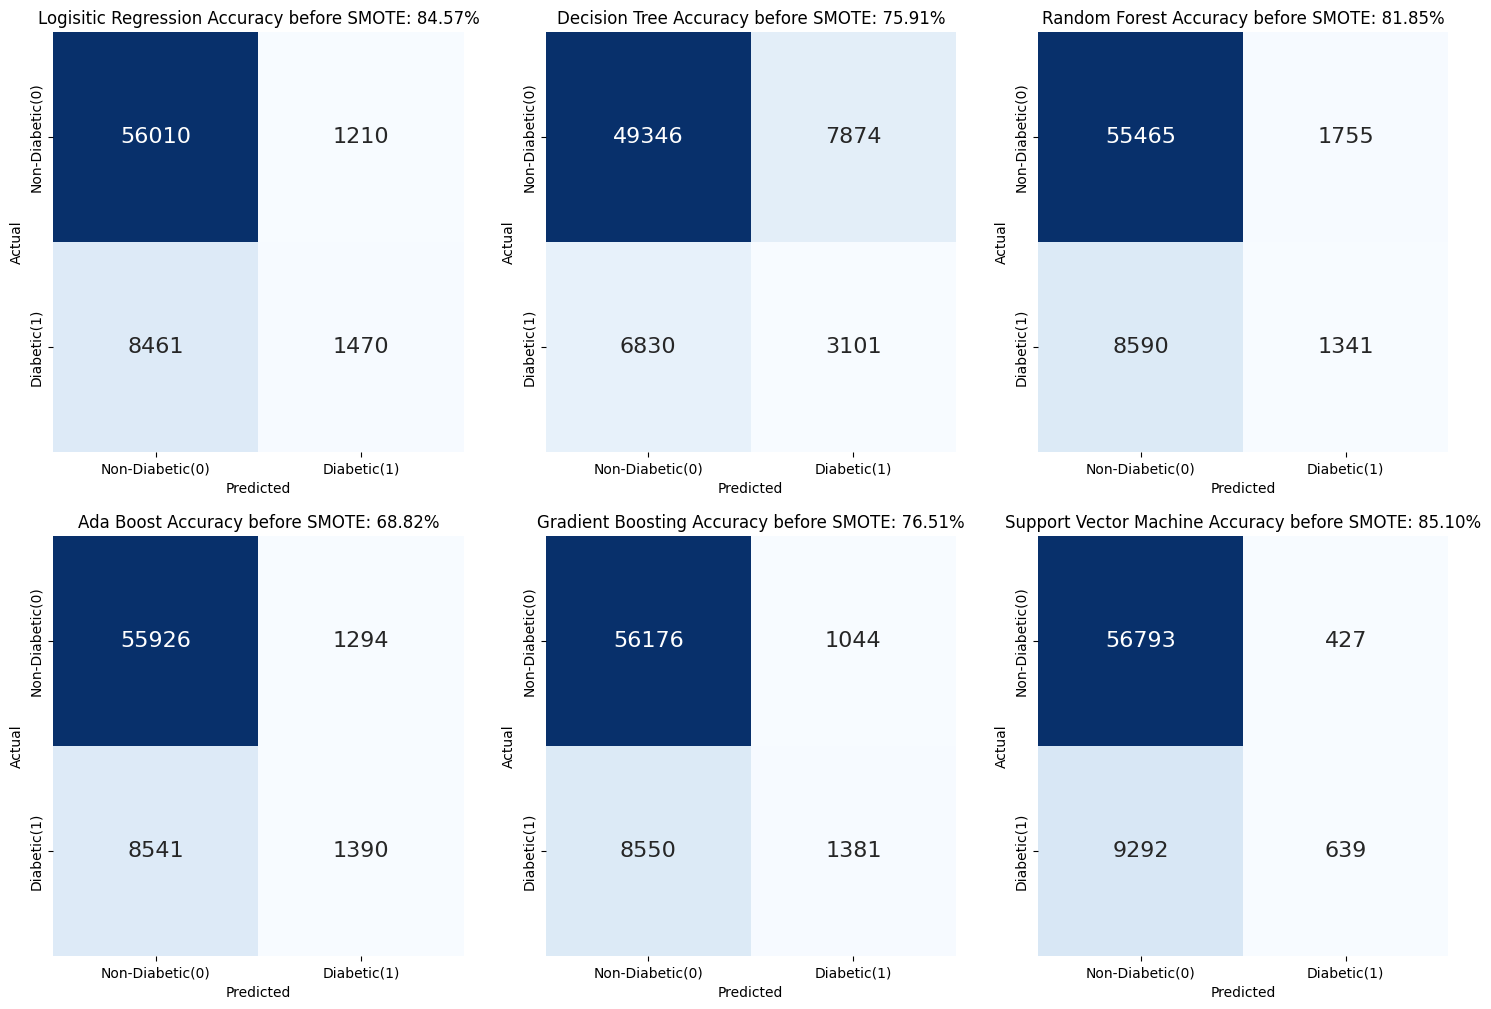

In [ ]:
# Confusion Matrix of all models before SMOTE
lr_cm = confusion_matrix(y_test, lr.predict(X_test_scaled))
dt_cm = confusion_matrix(y_test, dt.predict(X_test_scaled))
rf_cm = confusion_matrix(y_test, rf.predict(X_test_scaled))
ab_cm = confusion_matrix(y_test, ab.predict(X_test_scaled))
gb_cm = confusion_matrix(y_test, gb.predict(X_test_scaled))
svc_cm = confusion_matrix(y_test, svc.predict(X_test_scaled))


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sns.heatmap(lr_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][0]
            )
axes[0][0].set_title(f"Logisitic Regression Accuracy before SMOTE: {lr_acc_score:.2%}")
axes[0][0].set_xlabel("Predicted")
axes[0][0].set_ylabel("Actual")

sns.heatmap(dt_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][1]
            )
axes[0][1].set_title(f"Decision Tree Accuracy before SMOTE: {dt_acc_score:.2%}")
axes[0][1].set_xlabel("Predicted")
axes[0][1].set_ylabel("Actual")

sns.heatmap(rf_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][2]
            )
axes[0][2].set_title(f"Random Forest Accuracy before SMOTE: {rf_acc_score:.2%}")
axes[0][2].set_xlabel("Predicted")
axes[0][2].set_ylabel("Actual")


sns.heatmap(ab_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][0]
            )
axes[1][0].set_title(f"Ada Boost Accuracy before SMOTE: {ab_acc_score:.2%}")
axes[1][0].set_xlabel("Predicted")
axes[1][0].set_ylabel("Actual")


sns.heatmap(gb_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][1]
            )
axes[1][1].set_title(f"Gradient Boosting Accuracy before SMOTE: {gb_acc_score:.2%}")
axes[1][1].set_xlabel("Predicted")
axes[1][1].set_ylabel("Actual")


sns.heatmap(svc_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][2]
            )
axes[1][2].set_title(f"Support Vector Machine Accuracy before SMOTE: {svc_acc_score:.2%}")
axes[1][2].set_xlabel("Predicted")
axes[1][2].set_ylabel("Actual")

Text(1180.4281045751634, 0.5, 'Actual')

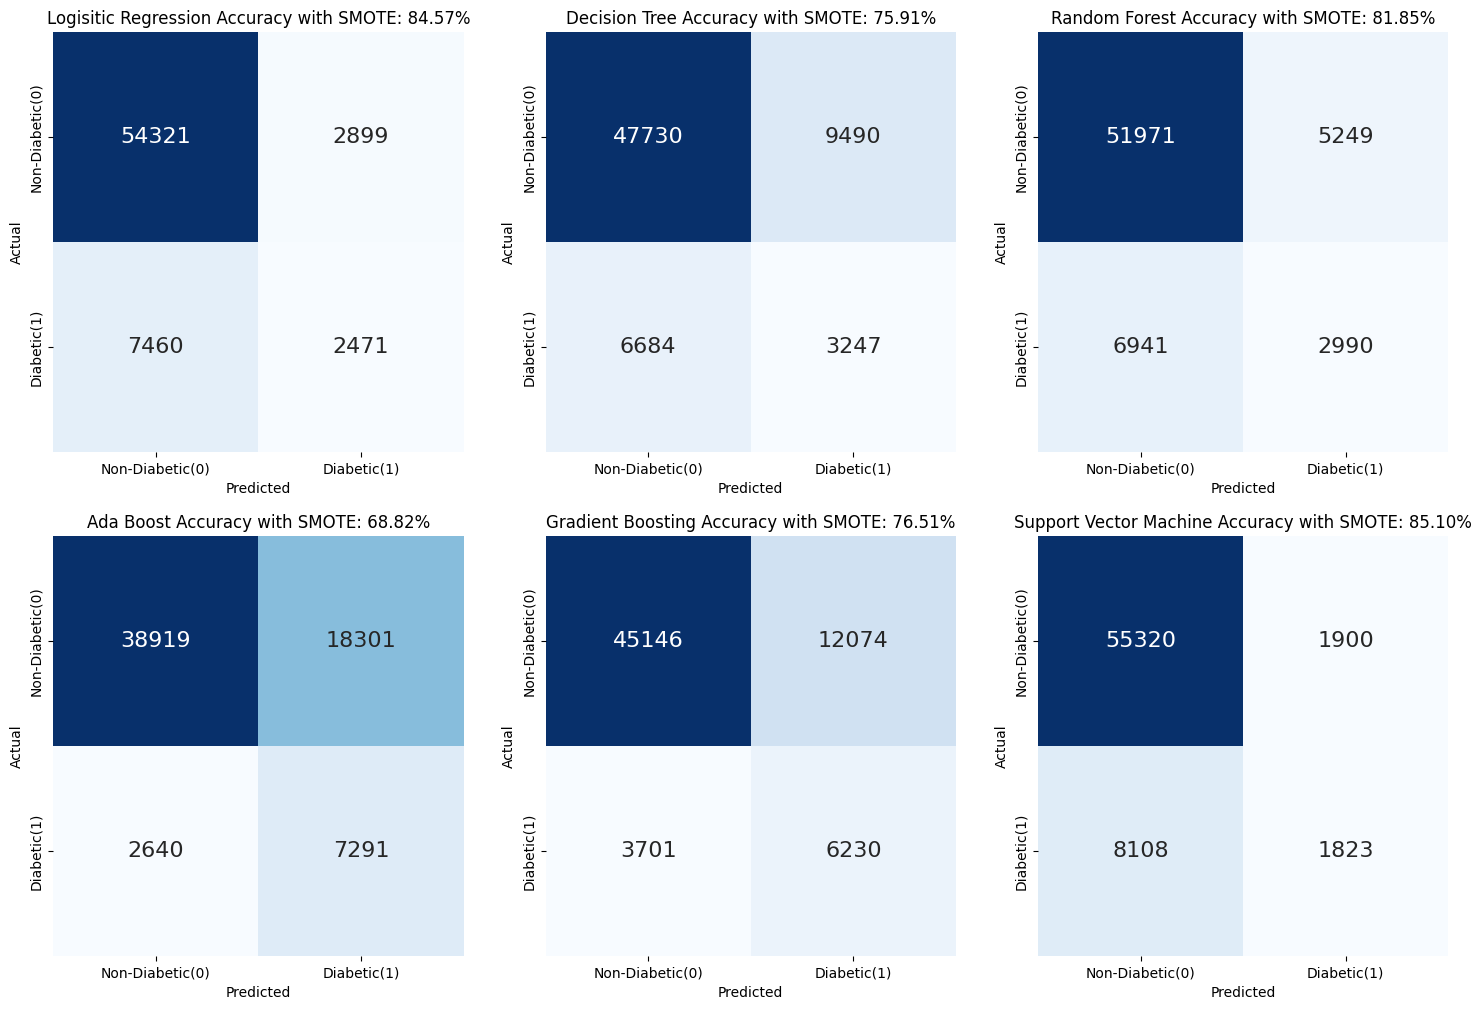

In [ ]:
lr_cm = confusion_matrix(y_test, log_pred_smote)
dt_cm = confusion_matrix(y_test, dt_pred_smote)
rf_cm = confusion_matrix(y_test, rf_pred_smote)
ab_cm = confusion_matrix(y_test, ab_pred_smote)
gb_cm = confusion_matrix(y_test, gb_pred_smote)
svc_cm = confusion_matrix(y_test, svc_pred_smote)


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sns.heatmap(lr_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][0]
            )
axes[0][0].set_title(f"Logisitic Regression Accuracy with SMOTE: {lr_acc_score:.2%}")
axes[0][0].set_xlabel("Predicted")
axes[0][0].set_ylabel("Actual")

sns.heatmap(dt_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][1]
            )
axes[0][1].set_title(f"Decision Tree Accuracy with SMOTE: {dt_acc_score:.2%}")
axes[0][1].set_xlabel("Predicted")
axes[0][1].set_ylabel("Actual")

sns.heatmap(rf_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][2]
            )
axes[0][2].set_title(f"Random Forest Accuracy with SMOTE: {rf_acc_score:.2%}")
axes[0][2].set_xlabel("Predicted")
axes[0][2].set_ylabel("Actual")


sns.heatmap(ab_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][0]
            )
axes[1][0].set_title(f"Ada Boost Accuracy with SMOTE: {ab_acc_score:.2%}")
axes[1][0].set_xlabel("Predicted")
axes[1][0].set_ylabel("Actual")


sns.heatmap(gb_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][1]
            )
axes[1][1].set_title(f"Gradient Boosting Accuracy with SMOTE: {gb_acc_score:.2%}")
axes[1][1].set_xlabel("Predicted")
axes[1][1].set_ylabel("Actual")


sns.heatmap(svc_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][2]
            )
axes[1][2].set_title(f"Support Vector Machine Accuracy with SMOTE: {svc_acc_score:.2%}")
axes[1][2].set_xlabel("Predicted")
axes[1][2].set_ylabel("Actual")

**Model Comparison using Evaluation Metrics (AFTER SMOTE)**:
- Accuracy: After applying SMOTE, accuracy shows a wider varience compared to pre-SMOTE models. SVM lead with the highest accuracy of 85.10% followed by Logistic Regression at 84.57%, Random Forest at 81.78%, Gradient boosting at 76.51%, Decision Tree at 75.78% and leaving ADA Boost as the lowest accuracy of 68.82%. By comparing SMOTE models with pre-SMOTE models, it reveals that SMOTE has resulted its models to drop in accuracy. However, accuracy is only defined based on the prediction rate of diabetic and non-diabetic cases. Thus, we will be investigating on the effects of SMOTE for the other evaluation metrics.
- Precision: Support Vector Machine is still effective in predicting diabetic cases correctly as it outperoms other models with a precision of 0.49 a drop from 0.60 after applying SMOTE. Unfortunately, Decision Tree still has the lowest precision of 0.25 in predicting diabetic cases and ADA Boost declines its precision rate by almost 50% to 0.28 from 0.52 leaving Gradient Boosting at 0.34, Random Forest at 0.36 and Logistic Regression at 0.46. On the other hand, all models performs exceptionally well in predicting non diabetic cases with Ada Boost leading at 0.94 followed by Gradient Boosting at 0.92, Logistic Regression, Random Forest and Decision Tree at 0.88 leaving the lowest precision by a margin to SVM at 0.87. When comparing the precision results for pre-smote models to smote models, precision generally improved for non-diabetics but decline for diabetic cases. 
- Recall: Ada Boost now dominates other models in identifying diabetic cases with a recall rate of 0.73 followed by Gradient Boost at 0.63 while Support Vector Machine still has the lowest recall rate of 0.18 which is an increase from 0.06 before applying SMOTE ). However, Support Vector Machine outperforms other models by a margin with a recall rate of 0.97 in identifying non-diabetic cases a 2% drop after applying SMOTE, followed by Logistic Regression at 0.95, leaving Ada Boost the lowest at 0.68. Generally, its recall rate of diabetic cases improved significantly after applying SMOTE which implies that SMOTE has successfully been able to learn more diabetics cases better.
- F1 Score: For the diabetic cases, Gradient Boost outperforms other models with a F1 Score of 0.44 followed by Ada Boost at 0.41. Despite having its highest accuracy, SVM has a lowest recall rate of 0.27. On the other hand for non-diabetic cases, SVM maintains its lead by having the F1 score of 0.92 followed by Logistic Regression at 0.91 and the lowest F1 goes to Ada Boost at 0.79. After applying SMOTE, it is observed that it has helped improved its F1 score for diabetic cases despite its slight decline for non-diabetic cases.


**Conclusion: Impact of SMOTE**
The introduction of SMOTE has successfully shifted its model focus. It is seen that while most model has extremely low recall rate for diabetic cases with a recall rate of less than 0.2, SMOTE has signficantly boosted recall rate of diabetic cases for Ada Boost (0.14 to 0.73) and Gradient Boost (0.14 to 0.63) implying that more diabetic cases are correctly classified. However, this improvement came at the cost of lower overall accuracy and precision, indicating an increase in false positives. This highlights the trade-off between detecting minority cases and maintaining overall prediction accuracy. For a medical screening tool, this trade-off is usually acceptable because it is better to perform a follow-up test on a healthy person than to miss out on a diabetic person completely.

**Choosing two suitable models for hyperparamter tuning**
We will be choosing Gradient Boosting and Ada Boost for hyperparameter tuning despite its low accuracy. Gradient Boosting offers the best balance in precision and recall among all models due to its highest F1 score for diabetic cases and with a strong recall of 0.63, it is able to correctly identify nearly 2/3 of diabetic cases. For Ada Boost, it is a clear choice given that the primary objective is to minimize the number of misclassfied diabetic patients due to its highest recall rate of 0.73 among all models in diabetic cases and its exclelent precision in predicting non-diabetic cases as it leads the models with a 0.94 precision meaning that it is exceptionally reliable in determining if a patient is healthy.

In [ ]:
# Define hyperparameters to tune for Gradient Boosting
# Use the gradientboost__ prefix to talk to the pipeline step
gb_param_grid = {
    'gradientboost__n_estimators': [10, 50, 100],
    'gradientboost__learning_rate': [0.1, 0.5, 1.0],
    'gradientboost__max_depth': [3, 5]

}

# Set up the Grid Search
gb_grid_search = GridSearchCV(
    estimator=gradient_boost_model, 
    param_grid=gb_param_grid, 
    cv=3, 
    verbose=3,
    n_jobs=-1                 
)

# Fit using SMOTE data
gb_grid_search.fit(X_train_sm, y_train_sm)

# 5. Print the best results
print("Best Parameters:", gb_grid_search.best_params_)


# 6. Get the best model
best_gb_model_pipe = gb_grid_search.best_estimator_

# Predict using the new best model
gb_tuned_pred = best_gb_model_pipe.predict(X_test)



Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'gradientboost__learning_rate': 1.0, 'gradientboost__max_depth': 5, 'gradientboost__n_estimators': 100}


In [ ]:
ada_param_grid = {'adaboost__n_estimators': [50, 150, 300]}

ada_grid_search = GridSearchCV(
    estimator=ada_boost_model,
    param_grid=ada_param_grid,
    cv=3,
    verbose=3,
    n_jobs=-1
)
# Fit on SMOTE data
ada_grid_search.fit(X_train_sm, y_train_sm)

# Print the best results
print("Best Parameters:", ada_grid_search.best_params_)

# Get the best model
best_ada_model_pipe = ada_grid_search.best_estimator_

# Results & Prediction

ab_tuned_pred = best_ada_model_pipe.predict(X_test) 



Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters: {'adaboost__n_estimators': 300}


# 8. Validation <a id='validation'></a>

[Back to top](#table_of_contents)

In [ ]:
print("Classification Report Before Tuning")
print("=" * 30)
print("\n")

# Gradient Boosting classification report
print(classification_report(y_test, gb_pred_smote))

# Gradient Boosting accuracy score
gb_acc_score = accuracy_score(y_test, gb_pred_smote)
print("Gradient Booster Accuracy Score: " + str(gb_acc_score) + "\n")




# Random Forest classification report
print(classification_report(y_test,ab_pred_smote))

# Random Forest accuracy score
ab_acc_score = accuracy_score(y_test, ab_pred_smote)
print("Ada Booster Accuracy Score: " + str(ab_acc_score) + "\n")





print("\n\nClassification Report After Tuning")
print("=" * 30)
print("\n")

# Logistic Regression classification report
print(classification_report(y_test, gb_tuned_pred))

# Logistic Regression accuracy score
gb_tuned_acc_score = accuracy_score(y_test, gb_tuned_pred)
print("Gradient Booster Accuracy Score: " + str(gb_tuned_acc_score) + "\n")


# Support Vector Machine classification report
print(classification_report(y_test, ab_tuned_pred))

# Support Vector Machine accuracy score
ab_tuned_acc_score = accuracy_score(y_test, ab_tuned_pred)
print("Ada Booster Accuracy Score: " + str(ab_tuned_acc_score) + "\n")




Classification Report Before Tuning


              precision    recall  f1-score   support

           0       0.92      0.79      0.85     57220
           1       0.34      0.63      0.44      9931

    accuracy                           0.77     67151
   macro avg       0.63      0.71      0.65     67151
weighted avg       0.84      0.77      0.79     67151

Gradient Booster Accuracy Score: 0.7650816815832974

              precision    recall  f1-score   support

           0       0.94      0.68      0.79     57220
           1       0.28      0.73      0.41      9931

    accuracy                           0.69     67151
   macro avg       0.61      0.71      0.60     67151
weighted avg       0.84      0.69      0.73     67151

Ada Booster Accuracy Score: 0.6881505859927626



Classification Report After Tuning


              precision    recall  f1-score   support

           0       0.88      0.92      0.90     57220
           1       0.38      0.29      0.33      9931

    

Text(956.631313131313, 0.5, 'Actual')

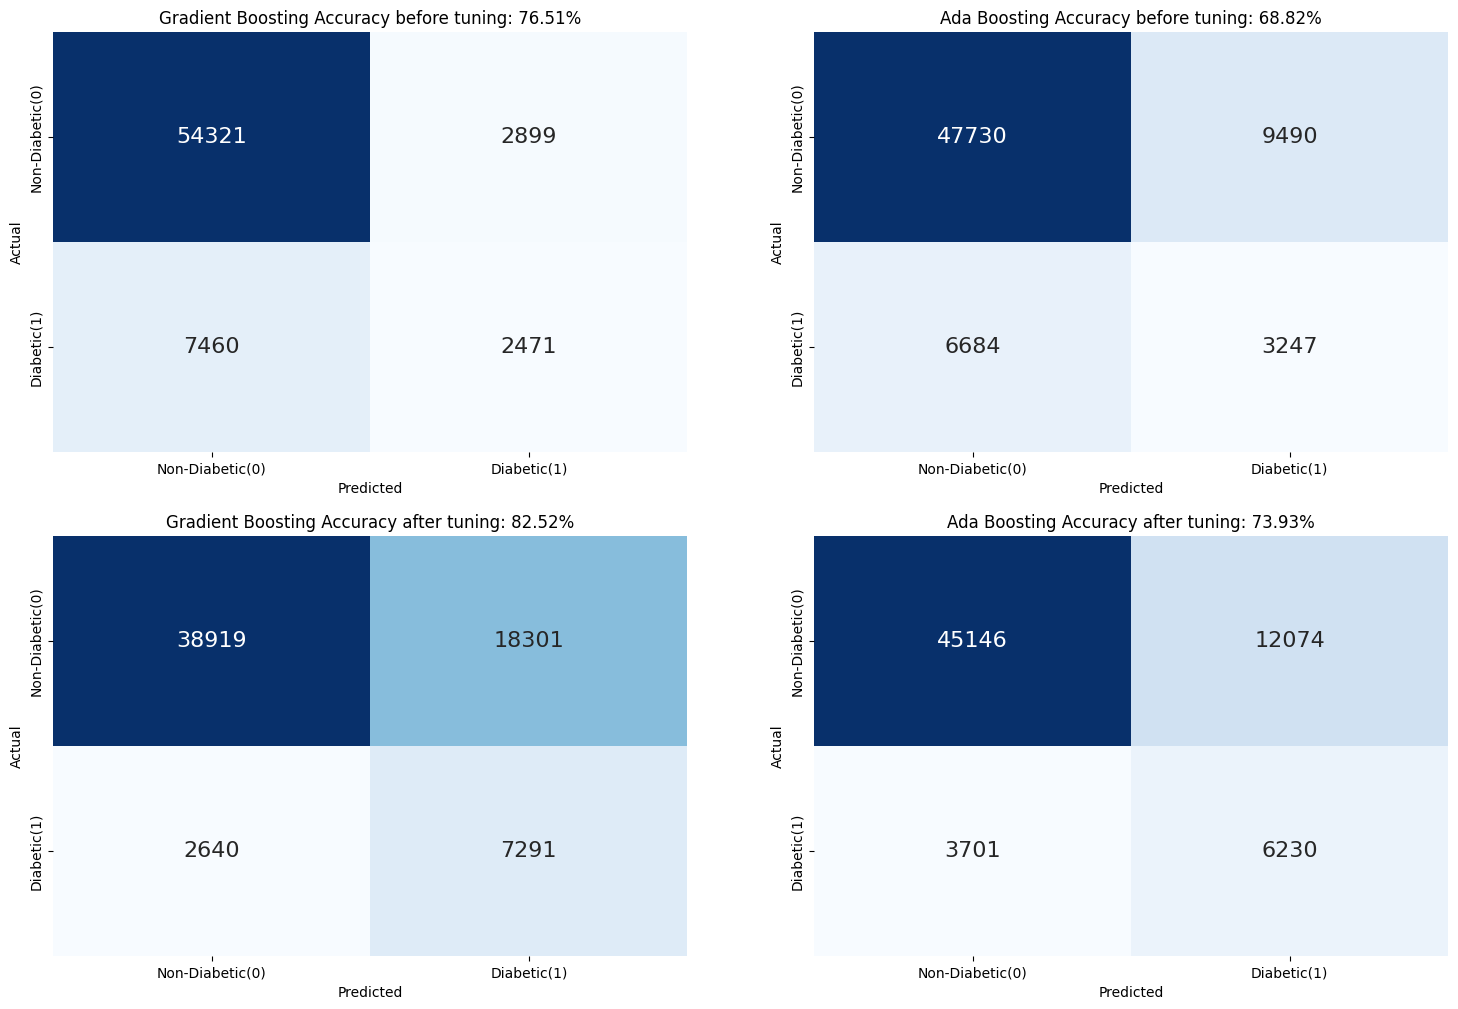

In [ ]:
gb_cm = confusion_matrix(y_test, gb_pred_smote)
ab_cm = confusion_matrix(y_test, ab_pred_smote)

gb_tuned_cm = confusion_matrix(y_test, gb_tuned_pred)
ab_tuned_cm = confusion_matrix(y_test, ab_tuned_pred)


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.heatmap(lr_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][0]
            )
axes[0][0].set_title(f"Gradient Boosting Accuracy before tuning: {gb_acc_score:.2%}")
axes[0][0].set_xlabel("Predicted")
axes[0][0].set_ylabel("Actual")

sns.heatmap(dt_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[0][1]
            )
axes[0][1].set_title(f"Ada Boosting Accuracy before tuning: {ab_acc_score:.2%}")
axes[0][1].set_xlabel("Predicted")
axes[0][1].set_ylabel("Actual")




sns.heatmap(ab_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][0]
            )
axes[1][0].set_title(f"Gradient Boosting Accuracy after tuning: {gb_tuned_acc_score:.2%}")
axes[1][0].set_xlabel("Predicted")
axes[1][0].set_ylabel("Actual")


sns.heatmap(gb_cm, annot=True, annot_kws={"size": 16},
            fmt='g', cmap='Blues', cbar=False, #cbar = False -> Disable count bar
            xticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            yticklabels=['Non-Diabetic(0)', 'Diabetic(1)'],
            ax = axes[1][1]
            )
axes[1][1].set_title(f"Ada Boosting Accuracy after tuning: {ab_tuned_acc_score:.2%}")
axes[1][1].set_xlabel("Predicted")
axes[1][1].set_ylabel("Actual")




**Model Comparison using Evaluation Metrics (AFTER Hyperparameter Tuning)**:
After identifying that Gradient Boosting and AdaBoost were more effective in handling SMOTE data, they are selected for hyperparameter tuning.
- Accuracy: Accuracy improved by a average of 5% for both models with Gradient Boosting achieving a higher accuracy of 82.52% followed by ADA Boosting at 73.93% after tuning.  
- Precision: Ada Boosting performs better in predicting non-diabetic cases at 0.93 precision than Gradient Boosting at 0.88. On the other hand, Gradient Boosting is more effective in predicting diabetic cases at 0.38 precision than Ada Booster at 0.32 precision. With the hyperparameter tuning effect, it is observed that it improved precision in predicting diabetic cases but decline for non-diabetic cases.
- Recall: Gradient Booster dominates Ada Boosting in identifying non-diabetic cases correctly with a 0.92 recall for Gradient Booster followed by 0.75 recall for Ada Boost. On the other hand, Ada Boosting is super effective in predicting diabetic cases with a 0.65 recall than a 0.29 recall from Gradient Boosting. The effect of hyperparameter tuning has improved its recall rate in non-diabetic cases but decline for diabetic cases.
- F1 Score: For the diabetic cases, Ada Boosting outperforms other models with a F1 Score of 0.43 followed by Gradient Boost at 0.33. On the other hand for non-diabetic cases, Gradient Boosting maintains its lead by having the F1 score of 0.9 followed by Ada Boosting at 0.83. The hyperparameter tuning effect has resulted its F1 score to improve for non-diabetic cases by both models and diabetic cases by Ada Boosting despite its decline of F1 score in diabetic cases by Gradient Boosting.


**Conclusion: Impact of Hyperparameter Tuning**
- The effect of hyperparameter tuning has not only boosted its accuracy of both model, but it also improved precision in diabetic cases prediction, recall in identifying non-diabetic cases correctly and improved F1 score in balancing precision and recall rate of non-diabetic cases.
- Given that the business objective is to predict the likelihood of individuals having diabetes based on individuals daily lifestyle and health indicators facilitating early detection and providing health recommendations for doctors, **Ada Boosting Model** will be selected in this business scenario. In medical screening, the cost of False Negative (misclassification of non-diabetic cases) is actually much higher than the False Positive (a healthy person that is misclassified as a diabetic case). Given that Ada Boosting recall of 0.65 is significantly higher than Gradient Boosting recall of 0.29, it implies Ada Boosting misses out about 35% of the diabetic cases while Gradient Boosting misses out 71% of diabetic cases. Thus, despite a lower accuracy by Ada Boosting, its superior recall and F1 score for diabetic cases can help ensure that health practitioners can identify and provide recommendations to the maximum number of at-risk individuals. Even if Gradient Boosting is more accurate, it is still not suitable to be used as a screening tool as it fails to identify majority of the diabetic cases.